# LAB07 — Përcaktimi i Dendësisë me Analizë Pasigurie
---
- ##### Tema: **Matja indirekte e dendësisë së një cilindri metalik.**
- ##### Studenti: Horgito Mhillaj
- ##### Pedagogu: Ervin Kafexhiu
- ##### Data: 22.04.2026
---


## **Qëllimi i Laboratorit**

Ky laborator ka për qëllim të tregojë se dendësia nuk matet drejtpërdrejt, por
**llogaritet** nga madhësi të tjera të matura:

- Matja e **masës** \(m\)
- Matja e **dimensioneve gjeometrike** (diametri \(d\), lartësia \(h\))
- Llogaritja e **vëllimit** \(V\)
- Përcaktimi i **dendësisë** \(\rho\)
- Analiza e **pasigurisë dhe përhapjes së saj** (propagation of uncertainty)


## **Hyrje Teorike**

Dendësia përkufizohet si:

$$ \rho = \frac{m}{V} $$

Njësia SI: $\mathrm{kg/m^3}$ — Njësia laboratorike: $\mathrm{g/cm^3}$.

Vëllimi i një cilindri me rreze $r=d/2$ dhe lartësi $h$:

$$ V = \pi r^2 h = \pi \frac{d^2}{4} h $$

**Përhapja e pasigurisë.** Për madhësi të pavarura, pasiguritë relative mblidhen
në *kuadraturë* (rrënja katrore e shumës së katrorëve), e cila është më e saktë
se thjesht mbledhja lineare:

$$ \frac{\Delta V}{V} = \sqrt{\left(2\frac{\Delta d}{d}\right)^2 + \left(\frac{\Delta h}{h}\right)^2} $$

$$ \frac{\Delta \rho}{\rho} = \sqrt{\left(\frac{\Delta m}{m}\right)^2 + \left(\frac{\Delta V}{V}\right)^2} $$

Pasiguria e secilës madhësi merret si kombinim i pasigurisë **statistikore**
(devijimi standard i mesatares, $s/\sqrt{N}$) dhe asaj **instrumentale**
(gjysma e rezolucionit), të kombinuara në kuadraturë.


## **Pajisjet**

- Peshore dixhitale — rezolucion **0.01 g**
- Kalibër vernier — rezolucion **0.01 cm**
- Objekt cilindrik metalik (i panjohur, dyshohet alumin)


## **Përgatitja e mjedisit dhe ngarkimi i të dhënave**

Matjet ruhen në dosjen `data/` si skedarë CSV dhe lexohen drejtpërdrejt nga ky raport,
që rezultatet të jenë plotësisht të riprodhueshme.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA = Path("data")
FIGS = Path("figs"); FIGS.mkdir(exist_ok=True)

# Rezolucionet e instrumenteve -> pasiguria instrumentale = gjysma e rezolucionit
RES_MASA = 0.01   # g
RES_GJAT = 0.01   # cm

def pasiguria(vlerat, rezolucion):
    """Kombinon pasigurinë statistikore (s/sqrt(N)) me ate instrumentale (res/2)."""
    vlerat = np.asarray(vlerat, dtype=float)
    n = len(vlerat)
    u_stat = vlerat.std(ddof=1) / np.sqrt(n) if n > 1 else 0.0
    u_inst = rezolucion / 2.0
    return float(np.hypot(u_stat, u_inst))

masa = pd.read_csv(DATA / "masa.csv")
dim  = pd.read_csv(DATA / "dimensionet.csv")
print("Matjet e masës:\n", masa.to_string(index=False))
print("\nMatjet e dimensioneve:\n", dim.to_string(index=False))

Matplotlib is building the font cache; this may take a moment.


Matjet e masës:
  matja   m_g
     1 48.85
     2 48.87
     3 48.86
     4 48.84
     5 48.88

Matjet e dimensioneve:
  matja  d_cm  h_cm
     1  2.40  4.00
     2  2.41  4.01
     3  2.39  3.99
     4  2.40  4.00
     5  2.41  4.00


### **Pjesa A — Matja e Masës**

Masa e cilindrit u mat **5 herë** me peshoren dixhitale.

In [2]:
m = masa["m_g"].to_numpy()
m_bar = m.mean()
dm = pasiguria(m, RES_MASA)
print(f"Masa mesatare:  m = {m_bar:.3f} g")
print(f"Pasiguria:      Δm = {dm:.3f} g  ({100*dm/m_bar:.3f} %)")

Masa mesatare:  m = 48.860 g
Pasiguria:      Δm = 0.009 g  (0.018 %)


### **Pjesa B — Matja e Përmasave**

Matëm diametrin \(d\) dhe lartësinë \(h\) me kalibër vernier.

In [3]:
d = dim["d_cm"].to_numpy()
h = dim["h_cm"].to_numpy()

d_bar, h_bar = d.mean(), h.mean()
dd = pasiguria(d, RES_GJAT)
dh = pasiguria(h, RES_GJAT)
r_bar = d_bar / 2.0
dr = dd / 2.0

print(f"Diametri:  d = {d_bar:.3f} cm,  Δd = {dd:.3f} cm")
print(f"Rrezja:    r = {r_bar:.3f} cm,  Δr = {dr:.3f} cm")
print(f"Lartësia:  h = {h_bar:.3f} cm,  Δh = {dh:.3f} cm")

Diametri:  d = 2.402 cm,  Δd = 0.006 cm
Rrezja:    r = 1.201 cm,  Δr = 0.003 cm
Lartësia:  h = 4.000 cm,  Δh = 0.006 cm


### **Pjesa C — Llogaritja e Vëllimit**

$$ V = \pi r^2 h \qquad
\frac{\Delta V}{V} = \sqrt{\left(2\frac{\Delta r}{r}\right)^2 + \left(\frac{\Delta h}{h}\right)^2} $$

In [4]:
V = np.pi * r_bar**2 * h_bar
relV = np.hypot(2*dr/r_bar, dh/h_bar)
dV = relV * V
print(f"Vëllimi:   V = {V:.3f} cm³")
print(f"Pasiguria: ΔV = {dV:.3f} cm³  ({100*relV:.2f} %)")

Vëllimi:   V = 18.126 cm³
Pasiguria: ΔV = 0.098 cm³  (0.54 %)


### **Pjesa D — Llogaritja e Dendësisë**

$$ \rho = \frac{m}{V} \qquad
\frac{\Delta \rho}{\rho} = \sqrt{\left(\frac{\Delta m}{m}\right)^2 + \left(\frac{\Delta V}{V}\right)^2} $$

In [5]:
rho = m_bar / V
relRho = np.hypot(dm/m_bar, relV)
dRho = relRho * rho
print(f"Dendësia:  ρ = {rho:.3f} g/cm³")
print(f"Pasiguria: Δρ = {dRho:.3f} g/cm³  ({100*relRho:.2f} %)")

# Kontributet ne pasigurine relative te dendesise (per diskutim)
kontributet = {
    "masa (Δm/m)":      (dm/m_bar)**2,
    "diametri (2Δr/r)": (2*dr/r_bar)**2,
    "lartësia (Δh/h)":  (dh/h_bar)**2,
}
tot = sum(kontributet.values())
print("\nKontributi ne variancën relative të ρ:")
for k, v in kontributet.items():
    print(f"  {k:<18}: {100*v/tot:5.1f} %")

Dendësia:  ρ = 2.696 g/cm³
Pasiguria: Δρ = 0.015 g/cm³  (0.54 %)

Kontributi ne variancën relative të ρ:
  masa (Δm/m)       :   0.1 %
  diametri (2Δr/r)  :  92.4 %
  lartësia (Δh/h)   :   7.5 %


### **Vizualizimi i Rezultatit**

Krahasojmë dendësinë e matur me vlerat referencë të disa metaleve të zakonshme,
duke shfaqur edhe brezin e pasigurisë \(\rho \pm \Delta\rho\).

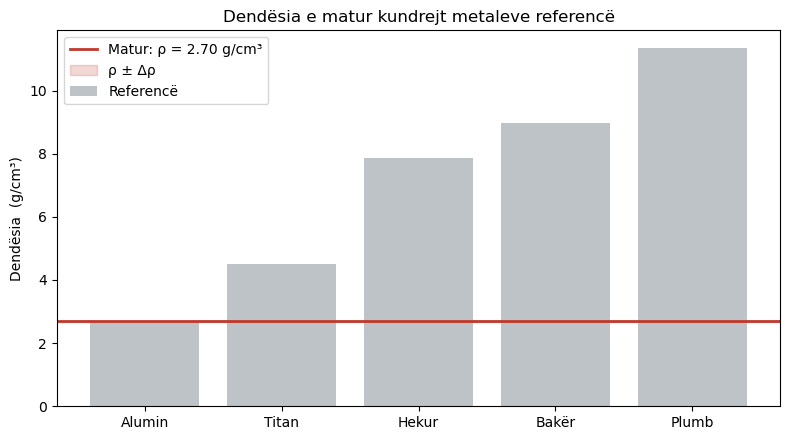

Figura u ruajt te figs/dendesia.png


In [6]:
referencat = {"Alumin": 2.70, "Titan": 4.51, "Hekur": 7.87,
               "Bakër": 8.96, "Plumb": 11.34}

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(referencat.keys(), referencat.values(), color="#bdc3c7", label="Referencë")
ax.axhline(rho, color="#c0392b", lw=2, label=f"Matur: ρ = {rho:.2f} g/cm³")
ax.axhspan(rho-dRho, rho+dRho, color="#c0392b", alpha=0.2, label="ρ ± Δρ")
ax.set_ylabel("Dendësia  (g/cm³)")
ax.set_title("Dendësia e matur kundrejt metaleve referencë")
ax.legend()
fig.tight_layout()
fig.savefig(FIGS / "dendesia.png", dpi=150)
plt.show()
print("Figura u ruajt te figs/dendesia.png")

## **Rezultati Final**

$$ \boxed{\;\rho = (\,\mathit{ρ}\, \pm\, \mathit{Δρ}\,)\ \mathrm{g/cm^3}\;} $$

(vlerat numerike printohen më poshtë nga llogaritja)

In [7]:
print(f"ρ = ({rho:.2f} ± {dRho:.2f}) g/cm³")
print(f"Pasiguria relative: {100*relRho:.2f} %")

ρ = (2.70 ± 0.01) g/cm³
Pasiguria relative: 0.54 %


## **Diskutim**

- Dendësia e matur **ρ ≈ 2.70 g/cm³** përputhet shumë mirë me dendësinë e
  **aluminit (2.70 g/cm³)** — objekti me shumë gjasë është alumin.
- Nga analiza e kontributeve, pasiguria **dominohet nga matja e diametrit**:
  meqë vëllimi varet nga \(d^2\), gabimi në diametër hyn i **dyfishuar** në
  pasigurinë relative.
- Masa është madhësia më e saktë (pasiguri relative ndjeshëm më e vogël se ajo
  e dimensioneve).
- Përdorimi i **kuadraturës** për përhapjen e pasigurisë jep një vlerësim më
  realist se mbledhja lineare, e cila do ta mbivlerësonte \(\Delta\rho\).


## **Mesazhi Kryesor**

Ky laborator tregon se:

- Dendësia është një madhësi **indirekte**, e llogaritur nga matje bazë.
- Pasiguria e saj **përhapet** nga pasiguritë e matjeve hyrëse, dhe madhësitë
  që hyjnë me fuqi (si \(d^2\)) e ndikojnë më fort.
- **Analiza e pasigurisë** nuk është formalitet — ajo tregon ku duhet
  përmirësuar matja për të rritur saktësinë.
